In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import pandas as pd
import torch.nn as nn
import optuna
from models import CondSM
from pathlib import Path
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

print(pd.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

def fit_affine_to_target(y_sm: torch.Tensor, y_tgt: torch.Tensor, eps: float = 1e-12, clamp_gain_nonneg: bool = False):
    """
    Fit a,b minimizing ||a*y_sm + b - y_tgt||^2 (least squares with intercept).
    Returns: (a, b, y_aff)
    """
    if not torch.is_tensor(y_sm):
        y_sm = torch.as_tensor(y_sm)
    if not torch.is_tensor(y_tgt):
        y_tgt = torch.as_tensor(y_tgt)
        
    y = y_sm.float().flatten()
    t = y_tgt.float().flatten()

    y_mean = y.mean()
    t_mean = t.mean()

    y0 = y - y_mean
    t0 = t - t_mean

    var_y = (y0 * y0).mean()
    cov_yt = (y0 * t0).mean()

    a = cov_yt / (var_y + eps)
    if clamp_gain_nonneg:
        a = torch.clamp(a, min=0.0)

    b = t_mean - a * y_mean
    y_aff = a * y_sm + b
    return a, b, y_aff

2.2.3
cuda


## compare mc and bo scores

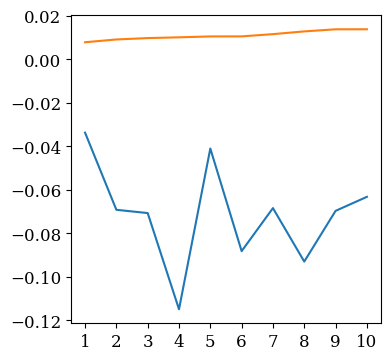

In [47]:
data_type = 'grad_away_1e7'
func_type = 'Cubic'

if func_type == 'Parabola':
    def target_func(x): return x**2
elif func_type == 'ReLU':
    def target_func(x): nn.ReLU()(x)
elif func_type == 'Cubic':
    def target_func(x): x**3
elif func_type == 'Sigmoid':
    def target_func(x): nn.Sigmoid()(x)

n = 50
x = torch.linspace(-1.5, 1.5, n)
y_tgt = target_func(x)

top_K_num = 10
mc_data = np.loadtxt(
        f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse/'
        f'topK_random_affine_data_type={data_type}_func={func_type}_cmin=-1.5_cmax=1.5_seed=42_maxl2=2.0_input_idx=3_K=100.txt'
)
mc_top_k_scores = mc_data[:top_K_num, -1]

bo_data = pd.read_csv(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO_mse/'
    f'bayes_opt_affine_data_type={data_type}_input_idx=3_func_type={func_type}_lambda_1=0.0__lambda_2=1.0_c_range=1.5.csv'
)
bo_top_k_scores = bo_data['target'].tolist()[:top_K_num]

fig, ax = plt.subplots(figsize=(4,4))

ax.plot(np.arange(1, top_K_num+1, 1), bo_top_k_scores)
ax.plot(np.arange(1, top_K_num+1, 1), mc_top_k_scores)
ax.set_xticks(np.arange(1, top_K_num+1, 1))
plt.show()